# Process data extracted from IFRC reports


In [2]:
import pandas as pd
import json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
from functions import *

In [3]:
fig_path = '/home/lhasbini/como_school/figure/'

In [4]:
#file_path = './Data/all_ifrc_reports_info_unnested_processed_v3.json'
file_path = '/scratchx/lhasbini/como_school/all_ifrc_reports_info_unnested_processed.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    all_ifrc_reports_info_unnested = json.load(json_file)

In [5]:
# filter for correct appeal type
filtered_reports = [
    disaster_report for disaster_report in all_ifrc_reports_info_unnested
    if disaster_report['appealType'] in ['Operations Update', 'DREF Operation', 'DREF Operation Final Report', 'DREF Operation Update']
]

In [6]:
# correct for hazard type
dict_hazards_grouped = {'Drought' : ['Drought', 'Dry Spell'],
                        'Flood' : ['Flood'],
                        'Cyclone' : ['Cyclone', 'Hurricane', 'Typhoon'],
                        'Storm' : ['Storm', 'Tornado'],
                        'Fire' : ['Fire', 'Wildfire'],
                        'Coldwave' : ['Coldwave'],
                        'Mass movement' : ['Mass movement'],
                        'Tsunami' : ['Tsunami']
                       }
filtered_reports = change_hazard(filtered_reports,dict_hazards_grouped)

In [7]:
list_disasters = []

for element in all_ifrc_reports_info_unnested:
    if (element['pdfDownloaded'] == 1):
        list_disasters.append(element['disasterTypeReclassified'])

In [8]:
for item in filtered_reports:
    if 'text' in item:
        item['text_processed'] = clean_text(item['text'])

## Tokenize reports into sentences

In [9]:
import nltk
nltk.download('punkt')  # Download the sentence tokenizer

from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /home/lhasbini/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [10]:
# Iterate over each dictionary in the list
for item in filtered_reports:
    # Tokenize the 'text' into sentence
    if 'text_processed' in item:
        sentences = sent_tokenize(item['text_processed'])
        # Append tokenized sentences back into the dictionary
        item['sentences'] = sentences

In [11]:
#reclassify hazards in the correct categories
hazard_patterns = {
        'Drought': r"drought.*|dry spell.*",
        'Flood': r"\b(flood|floods|flooding|inundation|inundations|glacial lake outburst)\b",
        'Storm': r"storm.*|superstorm.*|tornado.*|windstorm.*|snowstorm.*|snowfal.*|blizzard.*|derecho.*|winterstorm.*|hail.*|extra tropical storm.*|thunderstorm.*",
        #'Tornado': r"tornado.*",
        #'Hurricane': r"hurricane.*",
        'Storm surge': r"storm surge.*",
        'Heatwave': r"heat wave.*|heatwave.*|heat episode.*|((heat|hot) spell).*|heat stress.*",
        'Coldwave': r"cold wave.*|coldwave.*|severe winter conditions.*|cold spell.*",
        'Mass movement': r"land slide.*|landslide.*|rockfall.*|mudslide.*|mass movement.*",
        #'Earthquake': r"earthquake.*",
        'Cyclone': r"cyclone.*|tropical cyclone.*|hurricane.*|typhoon.*",
        #'Volcano': r"volcan.*",
        'Tidal Wave': r"tidal wav.*",
        'Wildfire': r"fire.*|forestfire.*|wildfire.*|landfire.*|bushfire.*|forest fire.*|wild fire.*|land fire.*|bush fire.*"
    }


In [12]:
for disaster_report in filtered_reports:
    if 'sentences' in disaster_report:
        sentences = disaster_report['sentences']
        hazard_list_all_sentences = []
        disaster_report['sentencesHazards'] = []
        for sentence in sentences:
            hazard_list = check_hazard_type_keyword(sentence, hazard_patterns)
            if hazard_list != 'None':
                if len(hazard_list) > 1:
                    disaster_report['sentencesHazards'].append(sentence)
                    hazard_list_all_sentences.append(hazard_list)
        disaster_report['hazard_list'] = hazard_list_all_sentences

In [13]:
#count single and multi-hazards
ifrc_reports_natural_hazards = []
count_multi = 0
count_single = 0
for element in filtered_reports:
    haz_set_unique = set()
    if  'hazard_list' in element:
        haz_set_unique = {tuple(hazlist) for hazlist in element['hazard_list']}
    element['haz_set_unique'] = haz_set_unique
    element['haz_list_unique'] = list(set([item for sublist in element['hazard_list'] for item in sublist]))
    #np.unique(np.array(np.array(filtered_reports[1]['hazard_list'])).flatten())

## Select headers 

In [17]:
# filtered_report_headers = []
# for rep in filtered_reports : 
#     rep_copy = rep.copy()
#     text = rep_copy['sentences']
#     header = select_hazard_description(text)
#     if len(header) >= 1 : 
#         rep_copy['sentences']=header 
#         filtered_report_headers.append(rep_copy)

# Identifying single events and compounding events

In [18]:
ifrc_reports_natural_hazards = []
count_multi = 0
count_single = 0
for element in filtered_reports:
    if ('haz_list_unique' in element):
        if len(element['haz_list_unique']) > 1:
            element['multiHazard'] = 1
            count_multi += 1
        else:
            element['multiHazard'] = 0
            count_single += 1

In [19]:
print(count_multi, "compound events")
print(count_single, "individual events")
print(count_multi+count_single, "total events")

362 compound events
317 individual events
679 total events


In [20]:
list_compound_hazards = []
for item in filtered_reports:
    #item['disasterTypeReclassified'] = item['disasterTypeReclassified'].split(', ')
    if len(item['haz_list_unique']) > 1:
        list_compound_hazards.append(item['haz_list_unique'])

In [21]:
list_compound_hazards_sentence = []
for item in filtered_reports:
    #item['disasterTypeReclassified'] = item['disasterTypeReclassified'].split(', ')
    if len(item['haz_list_unique']) > 1:
        for haz_sentence in item['haz_set_unique'] : 
            list_compound_hazards_sentence.append(haz_sentence)

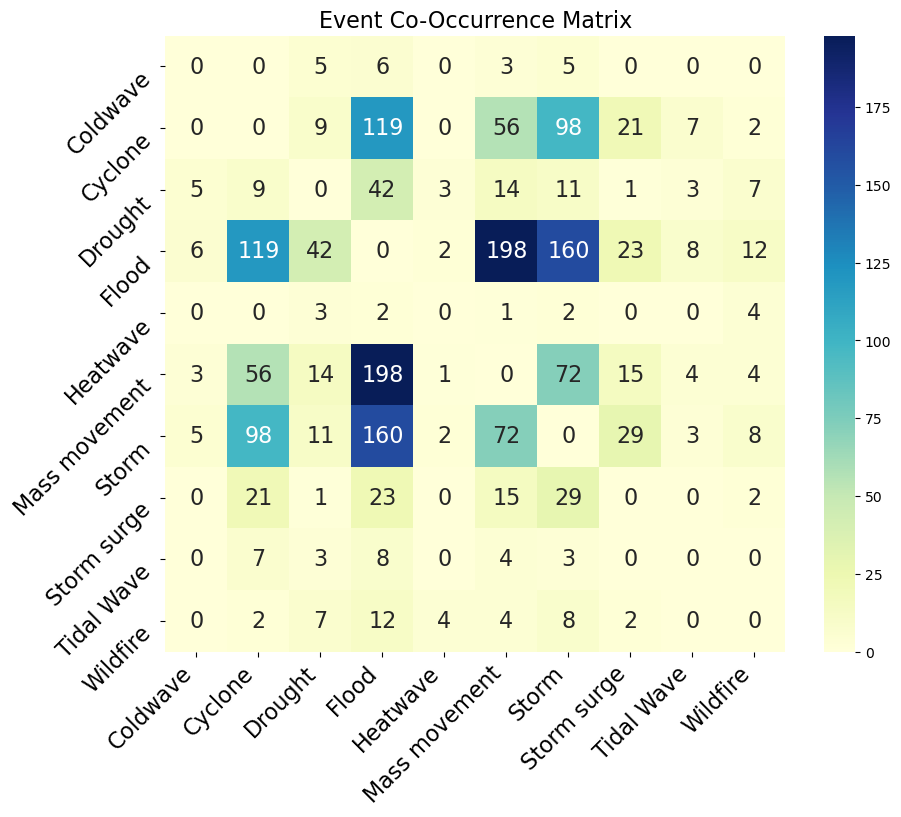

In [22]:
# Correlation matrix plot 
# Step 1: Identify unique events
unique_events = set()
for event_list in list_compound_hazards:
    unique_events.update(event_list)
unique_events = sorted(unique_events)

# Step 2: Create the co-occurrence matrix
co_occurrence_matrix = pd.DataFrame(0, index=unique_events, columns=unique_events)

for event_list in list_compound_hazards:
    #phrase_list = [phrase.strip() for phrase in event_list.split(',')]
    #print(event_list)
    for i in range(len(event_list)):
        for j in range(i, len(event_list)):
            #print(i, j)
            #print(event_list)
            if i != j:
                co_occurrence_matrix.loc[event_list[i], event_list[j]] += 1
                co_occurrence_matrix.loc[event_list[j], event_list[i]] += 1
            # else : 
            #     co_occurrence_matrix.loc[event_list[i], event_list[j]] += 1

# Step 3: Plot the matrix
fig=plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, annot=True, cmap="YlGnBu", fmt="d", 
            annot_kws={"size": 16})  # Increase annotation font size
plt.title("Event Co-Occurrence Matrix", fontsize=16)  # Increase title font size
#plt.xlabel("Your X-axis Label", fontsize=14)  # Optional: add X-axis label
#plt.ylabel("Your Y-axis Label", fontsize=14)  # Optional: add Y-axis label
plt.xticks(fontsize=16, rotation=45, ha='right')  # Increase x-axis tick font size
plt.yticks(fontsize=16, rotation=45, va='top')  # Increase y-axis tick font size
plt.show()
fig.tight_layout()
#fig.savefig(fig_path+"co_occurence_matrix_compound_sentences_merge.png", transparent=True)#, tight_layout=True)

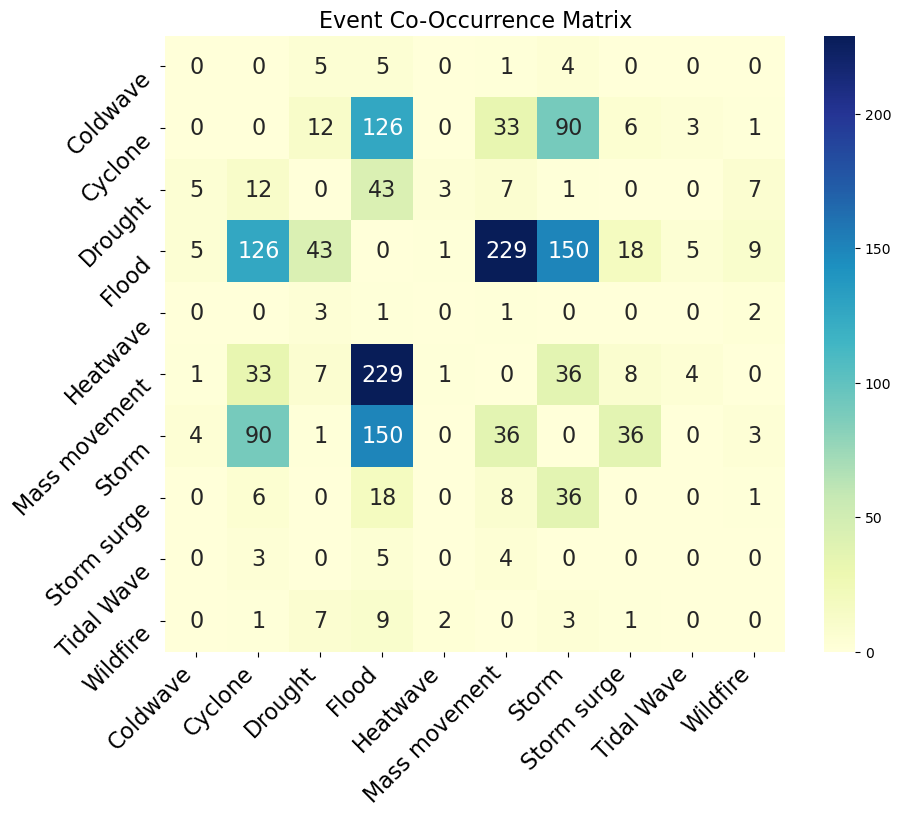

In [23]:
# Correlation matrix plot 
# Step 1: Identify unique events
unique_events = set()
for event_list in list_compound_hazards_sentence:
    unique_events.update(event_list)
unique_events = sorted(unique_events)

# Step 2: Create the co-occurrence matrix
co_occurrence_matrix = pd.DataFrame(0, index=unique_events, columns=unique_events)

for event_list in list_compound_hazards_sentence:
    #phrase_list = [phrase.strip() for phrase in event_list.split(',')]
    #print(event_list)
    for i in range(len(event_list)):
        for j in range(i, len(event_list)):
            #print(i, j)
            #print(event_list)
            if i != j:
                co_occurrence_matrix.loc[event_list[i], event_list[j]] += 1
                co_occurrence_matrix.loc[event_list[j], event_list[i]] += 1
            # else : 
            #     co_occurrence_matrix.loc[event_list[i], event_list[j]] += 1

# Step 3: Plot the matrix
fig=plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, annot=True, cmap="YlGnBu", fmt="d", 
            annot_kws={"size": 16})  # Increase annotation font size
plt.title("Event Co-Occurrence Matrix", fontsize=16)  # Increase title font size
#plt.xlabel("Your X-axis Label", fontsize=14)  # Optional: add X-axis label
#plt.ylabel("Your Y-axis Label", fontsize=14)  # Optional: add Y-axis label
plt.xticks(fontsize=16, rotation=45, ha='right')  # Increase x-axis tick font size
plt.yticks(fontsize=16, rotation=45, va='top')  # Increase y-axis tick font size
plt.show()
fig.tight_layout()
#fig.savefig(fig_path+"co_occurence_matrix_compound_sentences.png", transparent=True)#, tight_layout=True)

# Extract event name and date

In [16]:
nlp = spacy.load("en_core_web_sm")
report_sample = filtered_reports[:]

In [17]:
'oods' in report_sample[20]['sentencesHazards']

False

In [35]:
def extract_entities(text):
    # Process the text with spaCy
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

def extract_event_name_date(sentence):
    #entities = extract_entities(sentence)
    entities = extract_entities(sentence)
    dates = []
    places = []
    # Iterate over the tokens in the sentence
    for ent_set in entities:
        if ent_set[1] == 'DATE':
            dates.append(ent_set[0])

        if ent_set[1] == 'LOC':
            places.append(ent_set[0])
    return dates, places


In [36]:
#first need to extract entities
for report in report_sample:
    report['compound_dict'] = {}
    if len(report['sentencesHazards'])>0:
        #report['entities'] = extract_entities(report['sentencesHazards'])
        for i, sent_haz in enumerate(report['sentencesHazards']):
            haz_list = report['hazard_list'][i]
            multi_haz_name = ", ".join(haz_list)
            report['compound_dict'][multi_haz_name] = {}
            dates, places = extract_event_name_date(sent_haz)
            #report['compound_dict'][multi_haz_name]['hazards'] = haz_list
            report['compound_dict'][multi_haz_name]['dates'] = dates
            report['compound_dict'][multi_haz_name]['places'] = places



In [38]:
# irep = 20
# rep = report_sample[irep]
# print(rep["reportName"]+": "+rep['reportLink'])
# for i,sent in enumerate(rep['sentencesHazards']):
#     haz_list = rep['hazard_list'][i]
#     haz_list_str = ", ".join(haz_list)
#     print(sent)
#     print('-'*100)
#     print(haz_list_str+": ")
#     print(rep['compound_dict'][haz_list_str])
#     print('-'*100)
#     print('-'*100)

# Causal relationships

In [22]:
# Load the SpaCy English model
nlp = spacy.load("en_core_web_sm")

In [23]:
# Define a list of causal verbs
causal_verbs = ['cause', 'trigger', 'lead', 'result', 'bring', 'induce', 'exacerbate', 'contribute', 'prompt',
                'create', 'generate', 'produce', 'promote', 'force', 'drive', 'influence', 'encourage', 'stimulate', 'initiate']

In [24]:
# Function to extract causal relationships from a sentence

def extract_causal_relationships(sentence):
    doc = nlp(sentence)
    causes = []

    # Iterate over the tokens in the sentence
    for token in doc:
        # Check if the token is a verb and in the list of causal verbs
        if token.lemma_ in causal_verbs and token.pos_ == 'VERB':
            # Find the subject (nsubj) and object (dobj) of the verb
            subject = None
            effect = None

            for child in token.children:
                if child.dep_ == 'nsubj':  # Subject (the cause)
                    subject = child.text
                if child.dep_ in ['dobj', 'pobj']:  # Object (the effect)
                    effect = child.text

            # If both subject and object (effect) are found, return the relationship
            if subject and effect:
                causes.append((subject, token.lemma_, effect))

    return causes


In [25]:
# Apply the function to extract causal relationships
for disaster_report in filtered_reports:
    if 'sentencesHazards' in disaster_report:
        sentences = disaster_report['sentencesHazards']
        for sentence in sentences:
            causal_relations = extract_causal_relationships(sentence)
            if causal_relations:
                #print(f"Sentence: {sentence}")
                for cause in causal_relations:
                    if (len(check_hazard_type_keyword(cause[0], hazard_patterns))>0) and (len(check_hazard_type_keyword(cause[2],hazard_patterns))>0):
                        print(f"Sentence: {sentence}")
                        print(f"  Causal relationship: {cause[0]} -> {cause[2]} (via '{cause[1]}')")
                        print("----")

Sentence: Still suffering from Super Typhoon Goni, Bicol was the first to face Typhoon Vamcos winds and rain, as the typhoon triggered floods in parts of the region.
  Causal relationship: typhoon -> floods (via 'trigger')
----
Sentence: Meanwhile, on 8 April 2013, severe rainstorms caused further flooding and the destruction of property and farmlands in Agona East district in the Central region.
  Causal relationship: rainstorms -> flooding (via 'cause')
----
Sentence: Summary The announced intensive rain and snow storms that started on January 7th and are still striking large parts of the OPT have generated floods in several parts of the country.
  Causal relationship: storms -> floods (via 'generate')
----
Sentence: The hurricane caused flooding and landslides across Central Mexico as it passed over the Sierra Madre Oriental range.
  Causal relationship: hurricane -> flooding (via 'cause')
----
Sentence: The hurricane caused flooding and landslides across Central Mexico as it passed

In [26]:
# Apply the function to extract causal relationships
for disaster_report in filtered_reports[3:25]:
    sentences = disaster_report['sentencesHazards']
    for sentence in sentences:
        causal_relations = extract_causal_relationships(sentence)
        if causal_relations:
            print(f"Sentence: {sentence}")
            for cause in causal_relations:
                print(f"  Causal relationship: {cause[0]} -> {cause[2]} (via '{cause[1]}')")

Sentence: Total Tarbeted Population Women 10,250 Rural Urban Girls under 18 7,729 100 Men 10,171 People with disabilities estimated Boys under 18 8,180 1.58 Total targeted population 36,330 Page 14 23 Risk and security considerations Please indicate about potential operational risk for this operations and mitigation actions Risk Mitigation action Threat of southwest monsoon and potential new trop ical cyclones developing or entering the Philippine Area of Responsibility that enhance and inuence the country that could trigger more ooding, landslide and worsen the situation.
  Causal relationship: that -> ooding (via 'trigger')
Sentence: It is essential to note that volunteers and staff conducting fieldwork may also be at risk if sudden rainfall triggers landslides or flooding during their operations.
  Causal relationship: rainfall -> landslides (via 'trigger')
Sentence: 1, by which it activated the National Tropical Cyclone Warning Protocol and alerted government authorities and the Na